<a href="https://colab.research.google.com/github/angelcortez/titanic/blob/devAngelCortez/01_El_Undimiento_del_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# El Hundimiento del Titanic

La noche del 14 de abril de 1912, el RMS Titanic colisionó con un iceberg en el océano Atlántico durante su viaje inaugural de Southampton a Nueva York. Considerado uno de los barcos más lujosos y avanzados de su época, el Titanic se hundió durante la madrugada del 15 de abril, convirtiéndose en uno de los desastres marítimos más conocidos de la historia. Sin embargo, detrás de este acontecimiento histórico existen patrones y fenómenos que pueden analizarse mediante herramientas probabilísticas y estadísticas.

En esta actividad utilizaremos el dataset del hundimiento del Titanic para investigar, desde una perspectiva matemática, cómo factores como el sexo, la clase social, la edad o el puerto de embarque pudieron influir en las probabilidades de supervivencia de los pasajeros. A través de este análisis se aplicarán conceptos fundamentales de teoría de probabilidad y procesos estocásticos, tales como probabilidades marginales, probabilidades condicionales, operaciones entre eventos, independencia y la Regla de Bayes. El objetivo es interpretar los datos como un experimento aleatorio real y utilizar el razonamiento probabilístico para extraer conclusiones sobre uno de los eventos históricos más emblemáticos del siglo XX.

---

## Definición de eventos

Considere los siguientes eventos:

* N: “el pasajero sobrevivió”
* M: “el pasajero es hombre”
* W: “el pasajero es mujer”
* F: “el pasajero viajó en primera clase”
* G: “el pasajero viajó en segunda clase”
* T: “el pasajero viajó en tercera clase”

Para cada evento expresa la probabilidad en notación matemática en el siguiente bloque de Markdown (recuerda que Markdown es compatible con código de LaTeX para incluir expresiones matemáticas):

$$ P(N) = \frac{\text{sobrevivientes}}{\text{total de pasajeros}} $$

$$ P(M) = \frac{\text{pasajeros hombres}}{\text{total de pasajeros}} $$

$$ P(W) = \frac{\text{pasajeras mujeres}}{\text{total de pasajeros}} $$

$$ P(F) = \frac{\text{pasajeros en primera clase}}{\text{total de pasajeros}} $$

$$ P(G) = \frac{\text{pasajeros en segunda clase}}{\text{total de pasajeros}} $$

$$ P(T) = \frac{\text{pasajeros en tercera clase}}{\text{total de pasajeros}} $$

In [104]:
# CARGA DEL DATASET

import pandas as pd
df = pd.read_csv('titanic_sink_data.csv')
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


---
### Usando el dataset proporcionado realiza los cálculos pertinentes y responde a las siguientes preguntas

1. (Probabilidad marginal) ¿Cuál es la probabilidad de que un pasajero seleccionado al azar haya sobrevivido $P(N)$?

In [105]:
casos_favorables = len(df[df['Survived'] == 1])  # sobrevivientes
casos_totales = len(df)                          # total de pasajeros

pm_N = casos_favorables / casos_totales

print("P(N) = casos Favorables / casos totales")
print("P(N) = Pasajeros que sobrevivieron / Total de pasajeros en el barco")
print("-" * 65)
print(f"P(N) = {casos_favorables} / {casos_totales}")
print("-" * 65)
print(f"Probabilidad Marginal: P(N) = {pm_N:.4f} (o {pm_N * 100:.2f}%)")

P(N) = casos Favorables / casos totales
P(N) = Pasajeros que sobrevivieron / Total de pasajeros en el barco
-----------------------------------------------------------------
P(N) = 342 / 891
-----------------------------------------------------------------
Probabilidad Marginal: P(N) = 0.3838 (o 38.38%)


Respuesta: $P(N) = 38.38\% $

La probabilidad marginal es aquella que toma solo en cuenta una única variable, en este caso estamos analizando cuál es la probabilida dde que un pasajero al azar haya sobrevivido sin tomar en cuenta ningún otro aspecto.

2. (Probabilidad conjunta) ¿Cuál es la probabilidad de que un pasajero sea mujer y además haya sobrevivido $P(W \cap N) $?

In [106]:
# '&' es el operador AND que indica que se deben cumplir las dos condiciones
mujeres_sobrevivientes = len(df[(df['Sex'] == 'female') & (df['Survived'] == 1)]) # mujeres sobrevivientes
casos_totales = len(df)                          # total de pasajeros

pc_WANDN = mujeres_sobrevivientes / casos_totales

print("P(W ∩ N) = casos favorables / casos totales")
print("P(W ∩ N) = (mujeres que sobrevivieron) / (total de pasajeros)")
print("-" * 65)
print(f"P(W ∩ N) = {mujeres_sobrevivientes} / {casos_totales}")
print("-" * 65)
print(f"Probabilidad conjunta: P(W ∩ N) = {pc_WANDN:.4f} (o {pc_WANDN * 100:.2f}%)")

P(W ∩ N) = casos favorables / casos totales
P(W ∩ N) = (mujeres que sobrevivieron) / (total de pasajeros)
-----------------------------------------------------------------
P(W ∩ N) = 233 / 891
-----------------------------------------------------------------
Probabilidad conjunta: P(W ∩ N) = 0.2615 (o 26.15%)


Respuesta: $P(W \cap N) = 26.15\%$

La probabilidad conjunta es la probabilidad de que dos (o más) eventos ocurran al mismo tiempo. A diferencia de la probabilidad marginal que solo tiene en cuenta un evento independientemente del resto, en la probabilidad conjunta se considera la ocurrencia de dos o más eventos.

3. (Unión de eventos) ¿Cuál es la probabilidad de que un pasajero haya sobrevivido o viajado en primera clase? Toma en cuenta lo siguiente:

$$ P(N \cup F) = P(N) + P(F) - P(N\cap F) $$

In [107]:
casos_totales = len(df) # Espacio muestral (n)

# Pasajeros que sobrevivieron (N)
sobrevivientes = len(df[df['Survived'] == 1])
pm_N = sobrevivientes / casos_totales

# Pasajeros de primera clase (F)
primera_clase = len(df[df['Pclass'] == 1])
pm_F = primera_clase / casos_totales

# Intersección (N ∩ F) =  pasajeros que sobrevivieron y eran de primera clase
interseccion = len(df[(df['Survived'] == 1) & (df['Pclass'] == 1)])
p_N_and_F = interseccion / casos_totales

# P(N U F) = P(N) + P(F) - P(N ∩ F)
p_N_or_F = pm_N + pm_F - p_N_and_F

print("Fórmula de la Unión de Eventos:")
print("P(N U F) = P(N) + P(F) - P(N ∩ F)")
print("-" * 70)
print("Conteos totales:")
print(f"Total pasajeros (n)  = {casos_totales}")
print(f"Sobrevivieron (N)     = {sobrevivientes}")
print(f"Primera Clase (F)     = {primera_clase}")
print(f"Intersección (N ∩ F)  = {interseccion}")
print("-" * 70)
print("Cálculo de probabilidades:")
print(f"P(N) [Sobrevivieron]    = {sobrevivientes} / {casos_totales} = {pm_N:.4f}")
print(f"P(F) [Primera Clase]    = {primera_clase} / {casos_totales} = {pm_F:.4f}")
print(f"P(N ∩ F) [Intersección] = {interseccion} / {casos_totales} = {p_N_and_F:.4f}")
print("-" * 70)
print("Sustitución de valores en la fórmula:")
print(f"   P(N U F) = {pm_N:.4f} + {pm_F:.4f} - {p_N_and_F:.4f}")
print("-" * 70)
print(f"Unión de eventos: P(N U F) = {p_N_or_F:.4f} (o {p_N_or_F * 100:.2f}%)")

Fórmula de la Unión de Eventos:
P(N U F) = P(N) + P(F) - P(N ∩ F)
----------------------------------------------------------------------
Conteos totales:
Total pasajeros (n)  = 891
Sobrevivieron (N)     = 342
Primera Clase (F)     = 216
Intersección (N ∩ F)  = 136
----------------------------------------------------------------------
Cálculo de probabilidades:
P(N) [Sobrevivieron]    = 342 / 891 = 0.3838
P(F) [Primera Clase]    = 216 / 891 = 0.2424
P(N ∩ F) [Intersección] = 136 / 891 = 0.1526
----------------------------------------------------------------------
Sustitución de valores en la fórmula:
   P(N U F) = 0.3838 + 0.2424 - 0.1526
----------------------------------------------------------------------
Unión de eventos: P(N U F) = 0.4736 (o 47.36%)


Respuesta: $P(N \cup F) =47.36\%$

Dados dos eventos, definimos la unión como el evento formado por todos los elementos que están en A o en B. Es decir, el evento A U B se verifica cuando ocurre uno de los dos, A o en B, o ambos.

Para este caso es fundamental notar que los eventos "sobrevivir" y "viajar en primera clase" no son mutuamente excluyentes. Por ello, la fórmula matemática exige restar la intersección $P(N \cap F)$ tras sumar sus probabilidades marginales, de no hacerlo de esta manera, se estará contabilizando dos veces a los pasajeros de primera clase que sí sobrevivieron."


4. (Probabilidad condicional) ¿Cuál es la probabilidad de sobrevivir dado que el pasajero era mujer $P(N \mid W)$?

In [108]:
# Casos favorables: Mujeres que sobrevivieron (Intersección N ∩ W)
mujeres_sobrevivientes = len(df[(df['Sex'] == 'female') & (df['Survived'] == 1)])

# Nuevo espacio muestral: Total de mujeres (Condición W)
total_mujeres = len(df[df['Sex'] == 'female'])

# Calcular la probabilidad condicional
pc_N_dado_W = mujeres_sobrevivientes / total_mujeres

print("Fórmula de la Probabilidad Condicional:")
print("P(N | W) = P(N ∩ W) / P(W)")
print("P(N | W) = (Mujeres que sobrevivieron) / (Total de mujeres en el barco)")
print("-" * 70)

print("Sustitución de valores en la fórmula:")
print(f"   P(N | W) = {mujeres_sobrevivientes} / {total_mujeres}")
print("-" * 70)

print(f"Probabilidad condicional: P(N | W) = {pc_N_dado_W:.4f} (o {pc_N_dado_W * 100:.2f}%)")

Fórmula de la Probabilidad Condicional:
P(N | W) = P(N ∩ W) / P(W)
P(N | W) = (Mujeres que sobrevivieron) / (Total de mujeres en el barco)
----------------------------------------------------------------------
Sustitución de valores en la fórmula:
   P(N | W) = 233 / 314
----------------------------------------------------------------------
Probabilidad condicional: P(N | W) = 0.7420 (o 74.20%)


Respuesta: $P(N \mid W) =74.20\%$

La probabilidad condicional mide la probabilidad de que ocurra un suceso cuando ya ha ocurrido otro. Se determina relacionando la probabilidad conjunta de ambos sucesos con la probabilidad del suceso dado.

En este suceso podemos ver que existe una muy alta probabilidad de que sobreviviera y fuera mujer, debido a que como sabemos el criterio para salvar vidas fue primero ayudar a mujeres y niños.

5. (Probabilidad condicional inversa) ¿Cuál es la probabilidad de que un pasajero fuera mujer dado que sobrevivió $P(W \mid N)$?

In [109]:
# Casos favorables: Mujeres que sobrevivieron (Intersección W ∩ N)
mujeres_sobrevivientes = len(df[(df['Sex'] == 'female') & (df['Survived'] == 1)])

# espacio muestral: Total de personas que sobrevivieron (Condición N)
total_sobrevivientes = len(df[df['Survived'] == 1])

print(f"Mujeres que sobrevivieron = {mujeres_sobrevivientes}")
print(f"Total de sobrevivientes en el barco = {total_sobrevivientes}")

# Calcular la probabilidad condicional inversa
pci_W_dado_N = mujeres_sobrevivientes / total_sobrevivientes
print("-" * 70)
print("Fórmula de la Probabilidad Condicional Inversa:")
print("P(W | N) = P(W ∩ N) / P(N)")
print("P(W | N) = (Mujeres que sobrevivieron) / (Total de sobrevivientes)")
print("-" * 70)

print("Sustitución de valores en la fórmula:")
print(f"   P(W | N) = {mujeres_sobrevivientes} / {total_sobrevivientes}")
print("-" * 70)

print(f"Probabilidad condicional inversa: P(W | N) = {pci_W_dado_N:.4f} (o {pci_W_dado_N * 100:.2f}%)")

Mujeres que sobrevivieron = 233
Total de sobrevivientes en el barco = 342
----------------------------------------------------------------------
Fórmula de la Probabilidad Condicional Inversa:
P(W | N) = P(W ∩ N) / P(N)
P(W | N) = (Mujeres que sobrevivieron) / (Total de sobrevivientes)
----------------------------------------------------------------------
Sustitución de valores en la fórmula:
   P(W | N) = 233 / 342
----------------------------------------------------------------------
Probabilidad condicional inversa: P(W | N) = 0.6813 (o 68.13%)


Respuesta: $P(W \mid N) =68.13\%$

En punto anterior, tomamos en cuenta la probabilidad de salvarse si era mujer, mientras que en este punto primero tomamos en cuenta la población que se salvo y de ese espacio muestral determinamos cuál es la probabilidad de que sea mujer sí elegimos un pasajero al azar.

6. (Regla de Bayes) Utilizando la Regla de Bayes, calcule la probabilidad de que un pasajero haya viajado en primera clase dado que sobrevivió $P(F \mid N)$. Recuerda la *Regla de Bayes*:

$$P(A\mid B)=\frac{P(B\mid A)P(A)}{P(B)}$$

In [110]:
casos_totales = len(df)  # n

# P(N | F)
# Mujeres/Hombres de 1ra clase que sobrevivieron divididos entre el total de la 1ra clase
sobrevivientes_primera = len(df[(df['Survived'] == 1) & (df['Pclass'] == 1)])
total_primera = len(df[df['Pclass'] == 1])
pc_N_dado_F = sobrevivientes_primera / total_primera

# P(F)
pm_F = total_primera / casos_totales

# P(N)
sobrevivientes_totales = len(df[df['Survived'] == 1])
pm_N = sobrevivientes_totales / casos_totales

# --- Aplicar la Regla de Bayes ---
# P(F | N) = ( P(N | F) * P(F) ) / P(N)
pc_F_dado_N = (pc_N_dado_F * pm_F) / pm_N

print("Fórmula aplicada:")
print("P(F | N) = [ P(N | F) * P(F) ] / P(N)")
print("-" * 75)

print("Origen y cálculo de cada componente:")
print(f"P(N | F) [Sobreviviente dado que es 1ra clase] = {sobrevivientes_primera} / {total_primera} = {pc_N_dado_F:.4f}")
print(f"P(F)     [Marginal de 1ra clase]            = {total_primera} / {casos_totales} = {pm_F:.4f}")
print(f"P(N)     [Marginal de supervivencia]        = {sobrevivientes_totales} / {casos_totales} = {pm_N:.4f}")
print("-" * 75)

print("Sustitución de valores en el Teorema de Bayes:")
print(f"P(F | N) = ( {pc_N_dado_F:.4f} * {pm_F:.4f} ) / {pm_N:.4f}")
print(f"P(F | N) = {pc_N_dado_F * pm_F:.4f} / {pm_N:.4f}")
print("-" * 75)

print(f"Regla de Bayes: P(F | N) = {pc_F_dado_N:.4f} (o {pc_F_dado_N * 100:.2f}%)")

Fórmula aplicada:
P(F | N) = [ P(N | F) * P(F) ] / P(N)
---------------------------------------------------------------------------
Origen y cálculo de cada componente:
P(N | F) [Sobreviviente dado que es 1ra clase] = 136 / 216 = 0.6296
P(F)     [Marginal de 1ra clase]            = 216 / 891 = 0.2424
P(N)     [Marginal de supervivencia]        = 342 / 891 = 0.3838
---------------------------------------------------------------------------
Sustitución de valores en el Teorema de Bayes:
P(F | N) = ( 0.6296 * 0.2424 ) / 0.3838
P(F | N) = 0.1526 / 0.3838
---------------------------------------------------------------------------
Regla de Bayes: P(F | N) = 0.3977 (o 39.77%)


Respuesta: $P(F \mid N) = 39.77\%$

El teorema de Bayes establece una forma de calcular la probabilidad de un evento, teniendo en cuenta la probabilidad de eventos relacionados previamente observados. En otras palabras, nos permite actualizar nuestras creencias sobre la probabilidad de un evento a medida que obtenemos nueva información.


7. (Independencia de eventos) Determina si los eventos:

* “ser hombre”
* “sobrevivir”

son independientes.

Verifique si:


$$P(M \cap N)=P(M)P(N)$$


e interprete el resultado.

In [111]:
casos_totales = len(df)  # n

# Lado Izquierdo de la ecuación: P(M ∩ N)
# Pasajeros que son hombres y sobrevivieron
hombres_sobrevivientes = len(df[(df['Sex'] == 'male') & (df['Survived'] == 1)])
p_M_and_N = hombres_sobrevivientes / casos_totales

# Lado Derecho de la ecuación: P(M) * P(N)
# Probabilidad marginal de ser hombre P(M)
total_hombres = len(df[df['Sex'] == 'male'])
pm_M = total_hombres / casos_totales

# Probabilidad marginal de sobrevivir P(N)
total_sobrevivientes = len(df[df['Survived'] == 1])
pm_N = total_sobrevivientes / casos_totales

# Multiplicación del lado derecho
producto_marginales = pm_M * pm_N

print("Verificación de independencia matemática")
print("-" * 75)
print("Condición a verificar: P(M ∩ N) = P(M) * P(N)")
print("-" * 75)

print("Origen y cálculo de cada término:")
print(f"P(M ∩ N) [Hombres que sobrevivieron] = {hombres_sobrevivientes} / {casos_totales} = {p_M_and_N:.4f}")
print(f"P(M)     [Total hombres / Total]     = {total_hombres} / {casos_totales} = {pm_M:.4f}")
print(f"P(N)     [Total sobrevivieron / Total]= {total_sobrevivientes} / {casos_totales} = {pm_N:.4f}")
print("-" * 75)

print("Sustitución en la ecuación:")
print(f"Lado Izquierdo P(M ∩ N) : {p_M_and_N:.4f}")
print(f"Lado Derecho P(M)*P(N)  : {pm_M:.4f} * {pm_N:.4f} = {producto_marginales:.4f}")
print("-" * 75)

Verificación de independencia matemática
---------------------------------------------------------------------------
Condición a verificar: P(M ∩ N) = P(M) * P(N)
---------------------------------------------------------------------------
Origen y cálculo de cada término:
P(M ∩ N) [Hombres que sobrevivieron] = 109 / 891 = 0.1223
P(M)     [Total hombres / Total]     = 577 / 891 = 0.6476
P(N)     [Total sobrevivieron / Total]= 342 / 891 = 0.3838
---------------------------------------------------------------------------
Sustitución en la ecuación:
Lado Izquierdo P(M ∩ N) : 0.1223
Lado Derecho P(M)*P(N)  : 0.6476 * 0.3838 = 0.2486
---------------------------------------------------------------------------


Respuesta: $$0.1223 \neq 0.2486$$

Para que se consideren eventos independientes las probabilidades deberían ser iguales, en este caso no es así, por lo tanto se concluye que son eventos dependientes.

Esto demuestra matemáticamente el impacto que tuvo la política de evacuación "mujeres y niños primero", evidenciando que ser hombre disminuyó significativamente las posibilidades de supervivencia.

8. (Complemento de un evento) ¿Cuál es la probabilidad de que un pasajero **NO** haya sobrevivido $P(N^{c})$?

In [112]:
casos_totales = len(df)  # n

# Calcular la probabilidad de sobrevivir P(N)
pasajeros_sobrevivientes = len(df[df['Survived'] == 1])
pm_N = pasajeros_sobrevivientes / casos_totales

print(f"Probabilidad de que sobreviva un pasajero P(N): {pm_N}")

# Aplicar la fórmula del complemento
p_Nc = 1 - pm_N

print("Fórmula del Evento Complementario:")
print("P(Nᶜ) = 1 - P(N)")
print("-" * 70)
print("Sustitución de valores:")
print(f"   P(Nᶜ) = 1 - {pm_N:.4f}")
print("-" * 70)
print(f"Complemento de un evento: P(Nᶜ) = {p_Nc:.4f} (o {p_Nc * 100:.2f}%)")

Probabilidad de que sobreviva un pasajero P(N): 0.3838383838383838
Fórmula del Evento Complementario:
P(Nᶜ) = 1 - P(N)
----------------------------------------------------------------------
Sustitución de valores:
   P(Nᶜ) = 1 - 0.3838
----------------------------------------------------------------------
Complemento de un evento: P(Nᶜ) = 0.6162 (o 61.62%)


Respuesta: $P(N^{c}) = 61.62\%$

El complemento de un evento se calcula a través de restar a 1 (100%), la probabilidad del evento en sí.

En este caso ya habíamos calculado la probabilidad de que una persona sobreviviera (38.38%), por lo tanto, al restar 100% - 38.38% nos da como resultado 61.62%.


9. (Probabilidad condicional múltiple) ¿Cuál es la probabilidad de sobrevivir dado que el pasajero era mujer y viajaba en primera clase $P(N \mid W \cap F)$?

In [113]:
# Calcular los componentes de la condicional múltiple
# Casos favorables: Mujeres que sobrevivieron y que viajaban en primera clase (N ∩ W ∩ F)
favorables_multiple = len(df[(df['Sex'] == 'female') & (df['Pclass'] == 1) & (df['Survived'] == 1)])

# Nuevo espacio muestral: total de mujeres de primera clase (W ∩ F)
universo_condicion = len(df[(df['Sex'] == 'female') & (df['Pclass'] == 1)])

# Calcular la probabilidad
p_N_dado_W_and_F = favorables_multiple / universo_condicion

print("Fórmula de Probabilidad Condicional Múltiple:")
print("P(N | W ∩ F) = Casos Favorables / Casos Totales del Subgrupo")
print("P(N | W ∩ F) = (Mujeres de 1ra clase que sobrevivieron) / (Total de mujeres de 1ra clase)")
print("-" * 70)
print("Origen de los valores decimales:")
print(f"Mujeres de 1ra clase que sobrevivieron = {favorables_multiple}")
print(f"Total de mujeres de 1ra clase          = {universo_condicion}")
print("-" * 70)
print("Sustitución de valores en la fórmula:")
print(f"   P(N | W ∩ F) = {favorables_multiple} / {universo_condicion}")
print("-" * 70)
print(f"Probabilidad condicional múltiple: P(N | W ∩ F) = {p_N_dado_W_and_F:.4f} (o {p_N_dado_W_and_F * 100:.2f}%)")

Fórmula de Probabilidad Condicional Múltiple:
P(N | W ∩ F) = Casos Favorables / Casos Totales del Subgrupo
P(N | W ∩ F) = (Mujeres de 1ra clase que sobrevivieron) / (Total de mujeres de 1ra clase)
----------------------------------------------------------------------
Origen de los valores decimales:
Mujeres de 1ra clase que sobrevivieron = 91
Total de mujeres de 1ra clase          = 94
----------------------------------------------------------------------
Sustitución de valores en la fórmula:
   P(N | W ∩ F) = 91 / 94
----------------------------------------------------------------------
Probabilidad condicional múltiple: P(N | W ∩ F) = 0.9681 (o 96.81%)


Respuesta: $P(N \mid W \cap F) = 96.81\%$

En este punto se toman en cuenta dos condiciones de manera simultánea, que la persona sobreviviente sea mujer y haya viajado en primera clase, como podemos ver el resultado es muy alto, casi del 100%, lo que evidencia el privilegio para esta porción de la población que viajaba en el Titanic.

Practicamente si eras mujer y viajabas en primera clase, en caso de algún incidente, era seguro que sobrevivirías.


10. (Comparación entre probabilidades condicionales) Compara las siguientes probabilidades:

$$ P(N \mid F), \quad P(N \mid G), \quad P(N \mid T) $$

y responde:

* ¿Qué clase tuvo mayor probabilidad de supervivencia?
    - R= La Primera Clase $P(N | F)$ tuvo la mayor probabilidad de supervivencia, alcanzando aproximadamente un $62.96\%$, seguida de la segunda clase con un $47.28\%$, y finalmente la tercera clase en el punto más bajo
* ¿Existe evidencia de desigualdad socioeconómica en la supervivencia?
   - R= Sí, los datos revelan que existen variaciones importantes en las probabilidades de superviviencia entre cada clase, lo que nos indica que, al menos para este caso, sí había un punto importante de desigualdad, quizá al intentar salvar personas se dio preferencia a los de las clases más altas, o quizá los pasajeros de tercera clase estaban en partes muy inaccesibles del barco lo que dificultó que pudieran salir a tiempo.



   

P(N | F) [Sobrevivir dado 1ra Clase] = 136 / 216 = 0.6296 (62.96%)
P(N | G) [Sobrevivir dado 2da Clase] = 87 / 184 = 0.4728 (47.28%)
P(N | T) [Sobrevivir dado 3ra Clase] = 119 / 491 = 0.2424 (24.24%)
---------------------------------------------------------------------------
                                                                      
                                                                      
                                                                      
                                                                      
                                                                      
                                                                      
                                                                      
                                                                      
                                                                      


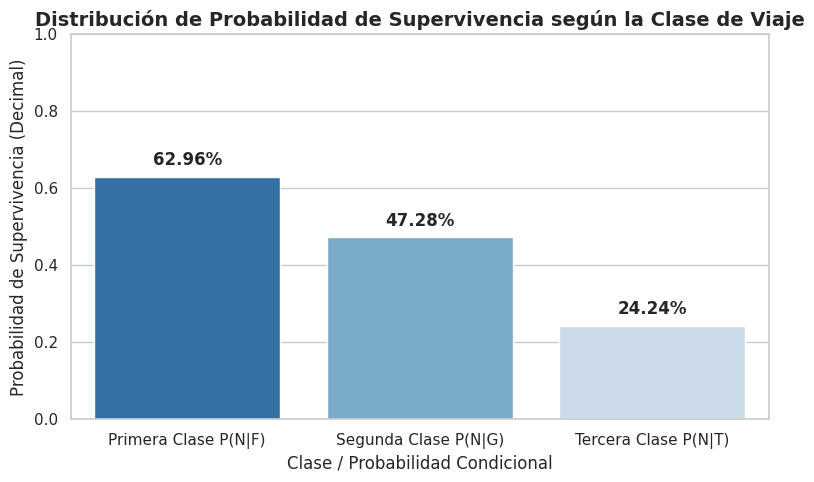

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular probabilidades condicionales para cada clase
# Primera clase P(N | F)
sobreviviente_F = len(df[(df['Pclass'] == 1) & (df['Survived'] == 1)])
total_pasajeros_F = len(df[df['Pclass'] == 1])
p_N_dado_F = sobreviviente_F / total_pasajeros_F

# Segunda clase P(N | G)
sobreviviente_G = len(df[(df['Pclass'] == 2) & (df['Survived'] == 1)])
total_pasajeros_G = len(df[df['Pclass'] == 2])
p_N_dado_G = sobreviviente_G / total_pasajeros_G

# Tercera clase P(N|T)
sobreviviente_T = len(df[(df['Pclass'] == 3) & (df['Survived'] == 1)])
total_pasajeros_T = len(df[df['Pclass'] == 3])
p_N_dado_T = sobreviviente_T / total_pasajeros_T

print(f"P(N | F) [Sobrevivir dado 1ra Clase] = {sobreviviente_F} / {total_pasajeros_F} = {p_N_dado_F:.4f} ({p_N_dado_F*100:.2f}%)")
print(f"P(N | G) [Sobrevivir dado 2da Clase] = {sobreviviente_G} / {total_pasajeros_G} = {p_N_dado_G:.4f} ({p_N_dado_G*100:.2f}%)")
print(f"P(N | T) [Sobrevivir dado 3ra Clase] = {sobreviviente_T} / {total_pasajeros_T} = {p_N_dado_T:.4f} ({p_N_dado_T*100:.2f}%)")
print("-" * 75)

# Gráfica
clases = ['Primera Clase P(N|F)', 'Segunda Clase P(N|G)', 'Tercera Clase P(N|T)']
probabilidades = [p_N_dado_F, p_N_dado_G, p_N_dado_T]

plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")
grafica = sns.barplot(x=clases, y=probabilidades, hue=clases, palette="Blues_r", legend=False)

# Etiquetas de la gráfica
plt.title('Distribución de Probabilidad de Supervivencia según la Clase de Viaje', fontsize=14, fontweight='bold')
plt.xlabel('Clase / Probabilidad Condicional', fontsize=12)
plt.ylabel('Probabilidad de Supervivencia (Decimal)', fontsize=12)
plt.ylim(0, 1.0) # Escala de 0 a 1

# Agregar los valores numéricos encima de cada barra
for i, prob in enumerate(probabilidades):
    grafica.text(i, prob + 0.02, f"{prob*100:.2f}%", ha='center', va='bottom', fontweight='bold')

print(" "*70)
print(" "*70)
print(" "*70)
print(" "*70)
print(" "*70)
print(" "*70)
print(" "*70)
print(" "*70)
print(" "*70)

plt.show()